# Tutorial 1: Integrating adjacent DLPFC slices
This tutorial demonstrates STAligner's ablility to integrate multiple adjacent slices. The slices are sampled from human dorsolateral prefrontal cortex (DLPFC) and the processed data can be downloaded from https://drive.google.com/drive/folders/1pHJy2cB9BKqc3ny9IpvVhiw_8ukJMzPW?usp=share_link.

## Preparation

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# import ST_utils
# import train_STAligner
import STAligner

# the location of R (used for the mclust clustering)
import os
#os.environ['R_HOME'] = "/home/xzhou/anaconda3/envs/PyG/lib/R"
#os.environ['R_USER'] = "/home/xzhou/anaconda3/envs/PyG/lib/python3.8/site-packages/rpy2"
import rpy2.robjects as robjects
import rpy2.robjects.numpy2ri


import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import scipy.linalg


import torch
used_device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

## Load Data

In [3]:
def mapping2int(string_array):
    mapping = {}
    result = []
    for string in string_array:
        if string not in mapping:
            mapping[string] = len(mapping)
        result.append(mapping[string])
    return result, mapping

import anndata as ad

#load data
count = pd.read_csv(
        "../../../data/Mouse_Brain/GSE147747/GSE147747_expr_raw_counts_table.tsv",
        sep="\t", index_col=0)
meta = pd.read_csv("../../../data/Mouse_Brain/GSE147747/GSE147747_meta_table.tsv",
                       sep="\t",
                       index_col=0)

In [4]:
adata_st_all = ad.AnnData(X=count.values)
adata_st_all.obs.index = count.index
adata_st_all.obs = meta.loc[adata_st_all.obs.index]
adata_st_all.var.index = count.columns

slice_use = ['01A', '02A', '03A', '04B', '05A', '06B', '07A', '08B', '09A', '10B',
                 '11A', '12A', '13B', '14A', '15A', '16A', '17A', '18A', '19A', '20B',
                 '21A', '22A', '23A', '24A', '25A', '26A', '27A', '28A', '29A', '30A',
                 '31A', '32A', '33A', '34A', '35A', ]


result, mapping = mapping2int(slice_use)

adata_st_all = adata_st_all[[s in slice_use for s in adata_st_all.obs.section_index.values]]
sc.pp.filter_cells(adata_st_all, min_genes=1)

In [5]:
Batch_list = []
adj_list = []
for i, slice_id in enumerate(sorted(set(adata_st_all.obs.section_index.values))):
        adata_tmp = adata_st_all[adata_st_all.obs.section_index.values == slice_id]
        array_col = np.array([np.float32(loc.split("_")[1].split("x")[0]) for loc in adata_tmp.obs.index])
        if slice_id == '01A':
            array_col = array_col - 0.3
        array_row = np.array([np.float32(loc.split("_")[1].split("x")[1]) for loc in adata_tmp.obs.index])
        
        adata_tmp.obs['array_col'] = np.round(array_col)
        adata_tmp.obs['array_row'] = np.round(array_row)

        adata_tmp.obs['batch_name'] = slice_id
        adata_tmp.obs['slice_id'] = mapping[slice_id]
        
        df = pd.DataFrame()
        df.loc[:,0] = adata_tmp.obs['array_col']
        df.loc[:,1] = adata_tmp.obs['array_row']
        adata_tmp.obsm['spatial'] = df
        
        adata_tmp.var_names_make_unique()
        
        adata_tmp = adata_tmp[:, (np.array(~adata_tmp.var.index.str.startswith("mt-"))
                                  & np.array(~adata_tmp.var.index.str.startswith("MT-")))]
        adata_tmp.obs.index = adata_tmp.obs.index + "-slice%d" % i

        adata_tmp = adata_tmp[~pd.isnull(adata_tmp.obs['ABA_parent'])]
        
        STAligner.Cal_Spatial_Net(adata_tmp, rad_cutoff=1.3) # the spatial network are saved in adata.uns[‘adj’]
        
        sc.pp.highly_variable_genes(adata_tmp, flavor="seurat_v3", n_top_genes=5000)
        sc.pp.normalize_total(adata_tmp, target_sum=1e4)
        sc.pp.log1p(adata_tmp)
        adata_tmp = adata_tmp[:, adata_tmp.var['highly_variable']]
        
        adj_list.append(adata_tmp.uns['adj'])
        Batch_list.append(adata_tmp)

------Calculating spatial graph...
The graph contains 546 edges, 152 cells.
3.5921 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 886 edges, 240 cells.
3.6917 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 998 edges, 269 cells.
3.7100 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 1216 edges, 326 cells.
3.7301 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 1354 edges, 361 cells.
3.7507 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 1504 edges, 403 cells.
3.7320 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 1844 edges, 488 cells.
3.7787 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 1768 edges, 470 cells.
3.7617 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 1826 edges, 491 cells.
3.7189

## Concat the scanpy objects for multiple slices

In [6]:
adata_concat = ad.concat(Batch_list, label="slice_name", keys=slice_use)
# adata_concat.obs['Ground Truth'] = adata_concat.obs['Ground Truth'].astype('category')
adata_concat.obs["batch_name"] = adata_concat.obs["slice_name"].astype('category')
print('adata_concat.shape: ', adata_concat.shape)

adata_concat.shape:  (17086, 132)


## Concat the spatial network for multiple slices

In [7]:
adj_concat = np.asarray(adj_list[0].todense())
for batch_id in range(1,len(slice_use)):
    adj_concat = scipy.linalg.block_diag(adj_concat, np.asarray(adj_list[batch_id].todense()))
adata_concat.uns['edgeList'] = np.nonzero(adj_concat)

## Running STAligner

In [8]:
%%time
adata_concat = STAligner.train_STAligner(adata_concat, verbose=True, knn_neigh = 50, device=used_device)

STAligner(
  (conv1): GATConv(132, 512, heads=1)
  (conv2): GATConv(512, 30, heads=1)
  (conv3): GATConv(30, 512, heads=1)
  (conv4): GATConv(512, 132, heads=1)
)
Pretrain with STAGATE...


100%|██████████| 500/500 [00:04<00:00, 113.72it/s]


Train with STAligner...


  0%|          | 0/500 [00:00<?, ?it/s]

Update spot triplets at epoch 500


100%|██████████| 500/500 [01:21<00:00,  6.15it/s] 


CPU times: total: 3min 19s
Wall time: 1min 26s


## Clustering

In [9]:
STAligner.ST_utils.mclust_R(adata_concat, num_cluster=15, used_obsm='STAligner')

# louvain
# sc.pp.neighbors(adata_concat, use_rep='STAligner', random_state=666)
# sc.tl.louvain(adata_concat, random_state=666, key_added="louvain", resolution=0.35)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


AnnData object with n_obs × n_vars = 17086 × 132
    obs: 'section_index', 'stereo_ML', 'stereo_DV', 'stereo_AP', 'HE_X', 'HE_Y', 'ABA_acronym', 'ABA_name', 'ABA_parent', 'nuclei_segmented', 'spot_radius', 'passed_QC', 'cluster_id', 'cluster_name', 'n_genes', 'array_col', 'array_row', 'batch_name', 'slice_id', 'slice_name', 'mclust'
    uns: 'edgeList'
    obsm: 'spatial', 'STAGATE', 'STAligner'

In [10]:
# sc.tl.umap(adata_concat, random_state=666)
# colors_default = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
#                   '#8c564b', '#e377c2', '#bcbd22', '#17becf', '#aec7e8',
#                   '#ffbb78', '#98df8a', '#ff9896', '#bec1d4', '#bb7784',
#                   '#0000ff']
# adata_concat.uns['louvain_colors'] = [colors_default[0:][i] for i in np.sort(adata_concat.obs['mclust'].unique().astype('int'))]
# 
# import matplotlib.pyplot as plt
# plt.rcParams['font.sans-serif'] = "Arial"
# plt.rcParams["figure.figsize"] = (2, 2)
# plt.rcParams['font.size'] = 10
# 
# sc.pl.umap(adata_concat, color=['batch_name', 'mclust'], ncols=2, wspace=1, show=True)

In [11]:
# for ss in range(len(section_ids)):
#     Batch_list[ss].obs['louvain'] = adata_concat[adata_concat.obs['batch_name'] == section_ids[ss]].obs['mclust'].values
#     Batch_list[ss].uns['louvain_colors'] = [colors_default[0:][i] for i in np.sort(adata_concat[adata_concat.obs['batch_name'] == 
#                                                                             section_ids[ss]].obs['mclust'].unique().astype('int'))]       
# 
# import matplotlib.pyplot as plt
# spot_size = 1
# title_size = 10
# fig, ax = plt.subplots(1, len(section_ids), figsize=(len(section_ids)*3, 3), gridspec_kw={'wspace':1, 'hspace': 0.1})    
# for ss in range(len(section_ids)-1):
#     _sc_0 = sc.pl.spatial(Batch_list[ss], img_key=None, color=['mclust'], title=['mclust'], size=1.5, legend_fontsize=8, 
#                   show=False, frameon=False, ax=ax[ss], spot_size=spot_size)
#     _sc_0[0].set_title(section_ids[ss], size=title_size)
# _sc_0 = sc.pl.spatial(Batch_list[-1], img_key=None, color=['mclust'], title=['mclust'], size=1.5, legend_fontsize=8, 
#               show=False, frameon=False, ax=ax[-1], spot_size=spot_size)
# _sc_0[0].set_title(section_ids[-1], size=title_size)
# plt.show()

In [12]:
#adata_concat.write('STAligner_MOB.h5ad')

In [13]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score

In [14]:
sub_adata = adata_concat[~pd.isnull(adata_concat.obs['ABA_parent'])]
ARI = ari_score(sub_adata.obs['ABA_parent'], sub_adata.obs['mclust'])
print(f"total ARI:{ARI}")
ARI_list = []
for name in slice_use:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    ARI = ari_score(sub_adata_tmp.obs['ABA_parent'], sub_adata_tmp.obs['mclust'])
    print(f"{name} ARI:{ARI}")
    ARI_list.append(ARI)
print('Mean:',np.mean(ARI_list))
print('Median:',np.median(ARI_list))

total ARI:0.269816123357077
01A ARI:0.2572613390004744
02A ARI:0.257032179717744
03A ARI:0.15427679210416548
04B ARI:0.217576970926881
05A ARI:0.2650886454084889
06B ARI:0.3056723717065256
07A ARI:0.3556279669742295
08B ARI:0.33852376531713174
09A ARI:0.3113856384543144
10B ARI:0.31246213233304587
11A ARI:0.3132853582679721
12A ARI:0.29170934257570685
13B ARI:0.311948529778929
14A ARI:0.34731751759382357
15A ARI:0.2944929348026022
16A ARI:0.31434936505584704
17A ARI:0.36041083471256924
18A ARI:0.3781984098341248
19A ARI:0.39759337610815315
20B ARI:0.39370224306054946
21A ARI:0.3950012020936376
22A ARI:0.39995702823221096
23A ARI:0.3742731496218328
24A ARI:0.2965293237831084
25A ARI:0.4189526980451439
26A ARI:0.34562475786267444
27A ARI:0.32147677734450814
28A ARI:0.31172452099494424
29A ARI:0.3267082881618848
30A ARI:0.35056074331644743
31A ARI:0.2947846925020225
32A ARI:0.32559368690747587
33A ARI:0.28997165779367945
34A ARI:0.33252897021073996
35A ARI:0.31734956993018476
Mean: 0.3222

In [15]:
sub_adata = adata_concat[~pd.isnull(adata_concat.obs['ABA_parent'])]
NMI = nmi_score(sub_adata.obs['ABA_parent'], sub_adata.obs['mclust'])
print(f"total NMI:{NMI}")
AMI = ami_score(sub_adata.obs['ABA_parent'], sub_adata.obs['mclust'])
print(f"total AMI:{AMI}")
NMI_list = []
AMI_list = []
for name in slice_use:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    NMI = nmi_score(sub_adata_tmp.obs['ABA_parent'], sub_adata_tmp.obs['mclust'])
    AMI = ami_score(sub_adata_tmp.obs['ABA_parent'], sub_adata_tmp.obs['mclust'])
    ACC = 1/2 * (NMI + AMI)
    print(f"{name} ACC:{ACC}")
    NMI_list.append(NMI)
    AMI_list.append(AMI)
print('NMI Mean:',np.mean(NMI_list))
print('NMI Median:',np.median(NMI_list))
print('AMI Mean:',np.mean(AMI_list))
print('AMI Median:',np.median(AMI_list))

total NMI:0.49846862659358304
total AMI:0.4972639875229159
01A ACC:0.3706095792259573
02A ACC:0.3580935701123358
03A ACC:0.3399465397303154
04B ACC:0.453710601454146
05A ACC:0.47706458983826006
06B ACC:0.5039415875125077
07A ACC:0.5231012705772768
08B ACC:0.5339995347098727
09A ACC:0.5361831347597803
10B ACC:0.541067620191626
11A ACC:0.5161439185187651
12A ACC:0.5353842500348559
13B ACC:0.5576303902155137
14A ACC:0.5691068894843065
15A ACC:0.5307515368936058
16A ACC:0.5488719853084547
17A ACC:0.5663644160136141
18A ACC:0.5794932603554838
19A ACC:0.5841000116319229
20B ACC:0.5773401841770532
21A ACC:0.5946420220916797
22A ACC:0.6196944444203056
23A ACC:0.5990786366603398
24A ACC:0.529451041384619
25A ACC:0.5620628612122927
26A ACC:0.546688384456604
27A ACC:0.54431294774904
28A ACC:0.5190344359367203
29A ACC:0.515418095820628
30A ACC:0.5055436707843755
31A ACC:0.47159335447345374
32A ACC:0.47335352464464847
33A ACC:0.4381500842541439
34A ACC:0.4761353083495346
35A ACC:0.4961174827702568


In [16]:
sub_adata = adata_concat[~pd.isnull(adata_concat.obs['ABA_parent'])]
HOM = hom_score(sub_adata.obs['ABA_parent'], sub_adata.obs['mclust'])
print(f"total HOM:{HOM}")
COM = com_score(sub_adata.obs['ABA_parent'], sub_adata.obs['mclust'])
print(f"total COM:{COM}")
V_list = []
for name in slice_use:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    HOM = hom_score(sub_adata_tmp.obs['ABA_parent'], sub_adata_tmp.obs['mclust'])
    COM = com_score(sub_adata_tmp.obs['ABA_parent'], sub_adata_tmp.obs['mclust'])
    V =  2 * ((HOM * COM) / (HOM + COM))
    print(f"{name} V:{V}")
    V_list.append(V)
print('V Mean:',np.mean(V_list))
print('V Median:',np.median(V_list))

total HOM:0.5431390030701702
total COM:0.46058767064682365
01A V:0.38270005513484384
02A V:0.36583643036617314
03A V:0.3553833555807567
04B V:0.46719614262108455
05A V:0.4907187274016172
06B V:0.5168544169626763
07A V:0.5330952104108014
08B V:0.5457887861025438
09A V:0.5466208725421727
10B V:0.5512095259646146
11A V:0.5282379096563979
12A V:0.5480516772878372
13B V:0.5694365169816449
14A V:0.5813789588617875
15A V:0.5445977898828784
16A V:0.5624102152373385
17A V:0.5784643834328037
18A V:0.5921765031077263
19A V:0.5965386662212712
20B V:0.5904153588667641
21A V:0.604960692750099
22A V:0.6295151663431413
23A V:0.6100019219188482
24A V:0.5422760188055303
25A V:0.5747721681215909
26A V:0.5586039408392082
27A V:0.5549018267542881
28A V:0.529118572121054
29A V:0.5258948779807636
30A V:0.5153634207609477
31A V:0.4807838228629837
32A V:0.4822297763821903
33A V:0.44468537660626867
34A V:0.48305789956968026
35A V:0.5061879535573613
V Mean: 0.528270426799934
V Median: 0.5445977898828784


5.733067382988246
1.3830687234137011


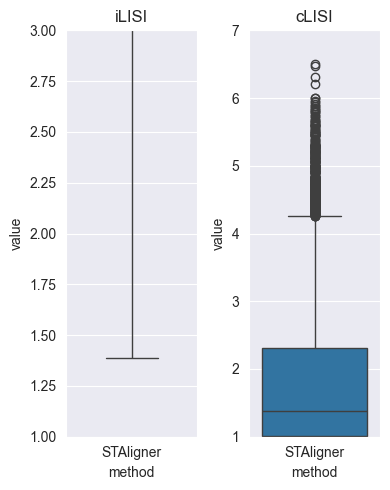

In [17]:
import seaborn as sns
import harmonypy as hm

iLISI = hm.compute_lisi(adata_concat.obsm['STAligner'], adata_concat.obs[['batch_name']], label_colnames=['batch_name'])[:, 0]
cLISI = hm.compute_lisi(adata_concat.obsm['STAligner'], adata_concat.obs[['ABA_parent']], label_colnames=['ABA_parent'])[:, 0]

df_iLISI = pd.DataFrame({
    'method': 'STAligner',
    'value': iLISI,
    'type': ['ILISI'] * len(iLISI)
})

df_cLISI = pd.DataFrame({
    'method': 'STAligner',
    'value': cLISI,
    'type': ['CLISI'] * len(cLISI)
})

fig, axes = plt.subplots(1, 2, figsize=(4, 5))
sns.boxplot(data=df_iLISI, x='method', y='value', ax=axes[0])
sns.boxplot(data=df_cLISI, x='method', y='value', ax=axes[1])
axes[0].set_ylim(1, 3)
axes[1].set_ylim(1, 7)
axes[0].set_title('iLISI')
axes[1].set_title('cLISI')

plt.tight_layout()
print(np.median(iLISI))
print(np.median(cLISI))